In [1]:
!apt-get install -y poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.6).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


In [2]:
pip install pdf2image

In [3]:
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import cv2
import imghdr
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D
from keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau

<ipython-input-4-05abc40879aa>:6: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [5]:
data_dir = '/content/drive/MyDrive/Dataset/USA currency'
image_exts = ['jpeg','jpg', 'png']
for image_class in os.listdir(data_dir):
    print(image_class)

Test Set
100 Dollar
2 Doolar
50 Dollar
10 Dollar
1 Dollar
5 Dollar


In [6]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print(f'Image not in ext list {image_path}')
                os.remove(image_path)
            else:
                with Image.open(image_path) as im:
                    # Remove ICC profile
                    im.info.pop('icc_profile', None)
                    im.save(image_path)
        except Exception as e:
            print(f'Issue with image {image_path}: {e}')
            os.remove(image_path)

In [7]:
X = []
Z = []
img_size = 224
One_Dollar_dir='/content/drive/MyDrive/Dataset/USA currency/1 Dollar'
Ten_Dollar_dir = '/content/drive/MyDrive/Dataset/USA currency/10 Dollar'
Hundred_Dollar_dir = '/content/drive/MyDrive/Dataset/USA currency/100 Dollar'
Two_Dollar_dir = '/content/drive/MyDrive/Dataset/USA currency/2 Doolar'
Five_Dollar_dir = '/content/drive/MyDrive/Dataset/USA currency/5 Dollar'
Fifty_dollar_dir = '/content/drive/MyDrive/Dataset/USA currency/50 Dollar'

In [8]:
def assign_label(img, currency_type):
  return currency_type

In [9]:
def make_train_data(currency_type, dir):
  for img in tqdm(os.listdir(dir)):
    label = assign_label(img, currency_type)
    path = os.path.join(dir, img)
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    img = cv2.resize(img, (img_size, img_size))

    X.append(np.array(img))
    Z.append(str(label))

In [10]:
make_train_data('One', One_Dollar_dir )
make_train_data('Ten', Ten_Dollar_dir )
make_train_data('hundred', Hundred_Dollar_dir )
make_train_data('Two', Two_Dollar_dir )
make_train_data('Five', Five_Dollar_dir )
make_train_data('Fifty', Fifty_dollar_dir )
print()
print(len(X))

100%|██████████| 685/685 [00:09<00:00, 71.95it/s]


3916


In [11]:
# Shuffle the combined data
X, Z = shuffle(X, Z, random_state=42)

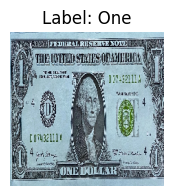

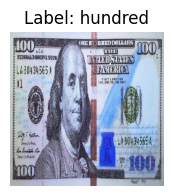

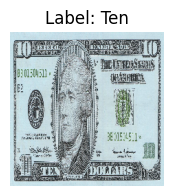

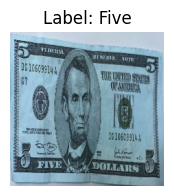

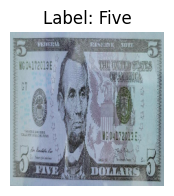

In [12]:
# Display a few images with their labels
for i in range(5):  # Show 5 examples
    plt.figure(figsize=(2, 2))
    plt.imshow(X[i])
    plt.title(f"Label: {Z[i]}")
    plt.axis('off')
    plt.show()

In [13]:
# Function to normalize the images
def normalize_images(X):
    return np.array(X) / 255.0

# Normalize the image data
X = normalize_images(X)

# Convert categorical labels to numeric values
le = LabelEncoder()
Y = le.fit_transform(Z)
Y = to_categorical(Y,6)

print(f"Total number of images: {len(X)}")

Total number of images: 3916


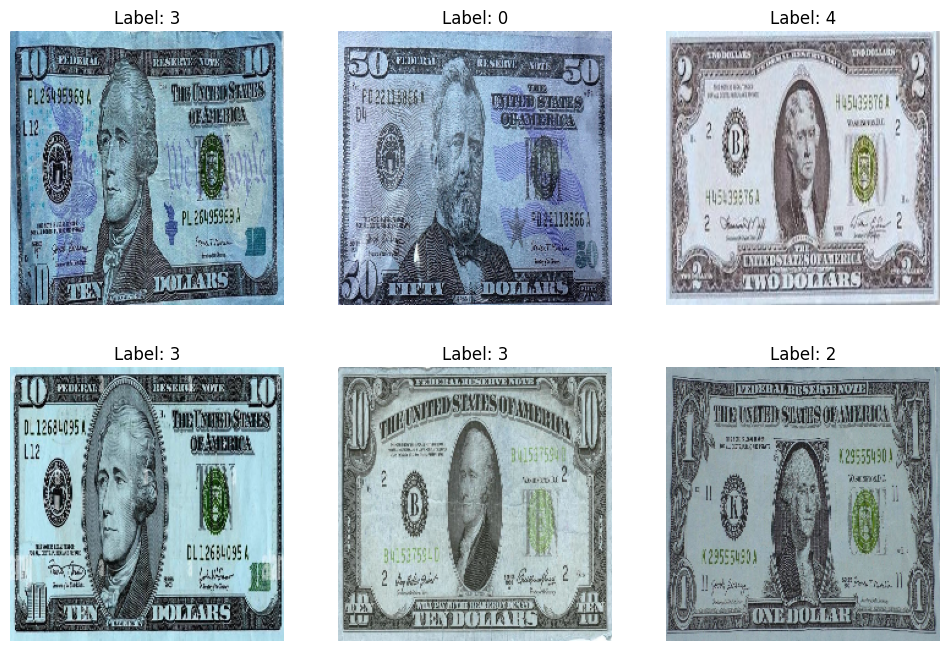

In [14]:
import matplotlib.pyplot as plt
import random

# Function to display random images with their labels
def display_random_images(X, Y, num_images=6):
    plt.figure(figsize=(12, 8))
    for i in range(num_images):
        index = random.randint(0, len(X) - 1)
        plt.subplot(2, 3, i + 1)
        plt.imshow(X[index])
        plt.title(f"Label: {np.argmax(Y[index])}")
        plt.axis('off')
    plt.show()

# Display 6 random images with their labels
display_random_images(X, Y, num_images=6)

In [15]:
# Split the data
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)  # 70% train, 30% temp
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=1/3, random_state=42 )  # 20% val, 10% test

print(f"Number of training images: {len(X_train)}")
print(f"Number of validation images: {len(X_val)}")
print(f"Number of test images: {len(X_test)}")

Number of training images: 2741
Number of validation images: 783
Number of test images: 392


In [16]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the pre-trained layers so they are not trainable
for layer in base_model.layers:
  layer.trainable = False

num_classes = 6

In [17]:
# Add custom layers on top of ResNet50
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Global average pooling layer to reduce the feature map dimensions
x = Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)  # Fully connected layer with 1024 units
x = Dropout(0.2)(x)  # Dropout layer to prevent overfitting
predictions = Dense(num_classes, activation='softmax')(x)  # Output layer with softmax activation for multi-class classification

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 25,692,038 (98.01 MB)

 Trainable params: 2,104,326 (8.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])



In [ ]:

# Train the model
history = model.fit(X_train, Y_train,
                    validation_data=(X_val, Y_val),
                    epochs=10,
                    batch_size=8)